# Simple linear regression - Exercise

You are given a real estate dataset. 

Real estate is one of those examples that every regression course goes through as it is extremely easy to understand and there is a (almost always) certain causal relationship to be found.

The data is located in the file: 'real_estate_price_size.csv'. 

You are expected to create a simple linear regression (similar to the one in the lecture), using the new data. 

Apart from that, please:
-  Create a scatter plot (with or without a regression line)
-  Calculate the R-squared
-  Display the intercept and coefficient(s)
-  Using the model make a prediction about an apartment with size 750 sq.ft.

Note: In this exercise, the dependent variable is 'price', while the independent variable is 'size'.

Good luck!

## Import the relevant libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

## Load the data

In [2]:
data_raw = pd.read_csv("real_estate_price_size.csv")
data_raw.head()

,price,size
0,234314.144,643.09
1,228581.528,656.22
2,281626.336,487.29
3,401255.608,1504.75
4,458674.256,1275.46


## Create the regression

### Declare the dependent and the independent variables

In [11]:
p_y = data_raw["price"]
p_X = data_raw[["size"]]

### Explore the data

In [8]:
data_raw.describe()

,price,size
count,100.000000,100.000000
mean,292289.470160,853.024200
std,77051.727525,297.941951
min,154282.128000,479.750000
25%,234280.148000,643.330000
50%,280590.716000,696.405000
75%,335723.696000,1029.322500
max,500681.128000,1842.510000


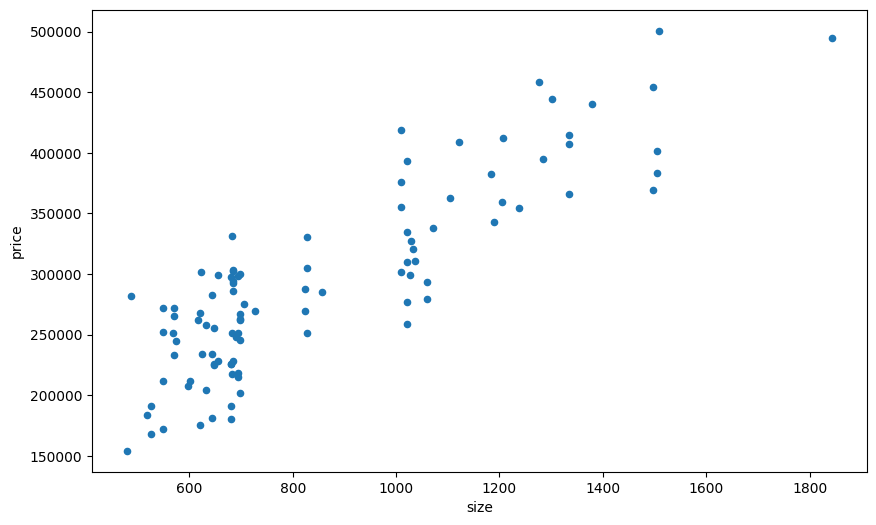

In [24]:
fig, ax = plt.subplots(figsize=(10,6))
data_raw.plot(x="size", y="price", kind="scatter", ax=ax)
plt.show()

### Transform the inputs into a matrix (2D object)

In [13]:
y = p_y.to_numpy()
X = p_X.to_numpy()
(X.shape, y.shape)

((100, 1), (100,))

### Regression itself

In [14]:
model = LinearRegression().fit(X, y)

### Calculate the R-squared

In [16]:
model.score(X, y)

0.7447391865847586

### Find the intercept

In [17]:
model.intercept_

np.float64(101912.60180122906)

### Find the coefficients

In [18]:
model.coef_

array([223.17874259])

### Making predictions

You find an apartment online with a size of 750 sq.ft.

All else equal what should be its price according to the model?

In [45]:
model.predict([[750]])

array([269296.65874718])

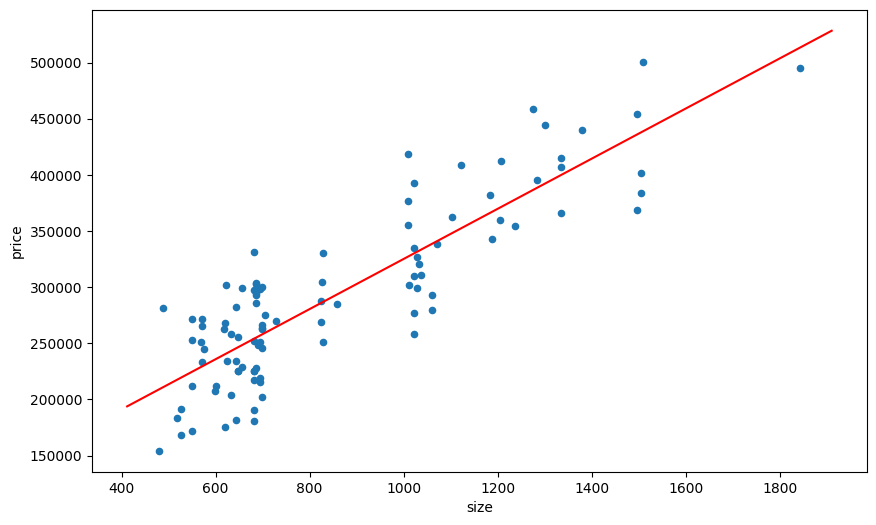

In [43]:
fig, ax = plt.subplots(figsize=(10,6))
data_raw.plot(x="size", y="price", kind="scatter", ax=ax)
xmin, xmax = ax.get_xlim()
x_pred = np.linspace(xmin, xmax, 20)
y_pred = model.predict(x_pred.reshape(-1, 1))
ax.plot(x_pred, y_pred, "r-")
plt.show()